In [120]:
import os
import matplotlib.pyplot as plt
import numpy as np
from qutip import qeye, wigner 


# 7 klas stanów
from state.fock import FockState 
from state.cat import CatState
from state.thermal import ThermalState
from state.coherent import CoherentState
from state.binomal import BinomialState
from state.gkp import GKPState
from state.vacuum import VacuumState

In [121]:
FOLDER = "data/fock_n2"
os.makedirs(FOLDER, exist_ok=True)
rng = np.random.default_rng()

In [122]:
fock2 = FockState(n=2, cutoff=20)
rho = fock2.density_matrix()

In [ ]:
# qeye = identity matrix
identity = qeye(fock2.cutoff) / fock2.cutoff

for i in range(1000):
    p = rng.random()
    rho_noisy = p * rho + (1 - p) * identity
    xvec = np.linspace(-5, 5, 200)
    W = wigner(rho_noisy, xvec, xvec)

    fig = plt.figure(figsize=(1.28, 1.28), dpi=100)
    ax = fig.add_axes([0, 0, 1, 1]) # Obraz zajmuje całe pole, bez marginesów
    
    # funkcja Wignera
    ax.imshow(W, cmap='RdBu', extent=[-5, 5, -5, 5])
    
    # Usuń śmieci 
    ax.axis('off') 
    
    file_name = f"fock2_ID{i:04d}_p{p:.4f}.png"
    file_path = os.path.join(FOLDER, file_name)
    
    plt.savefig(file_path, format='png')
    plt.close(fig) 

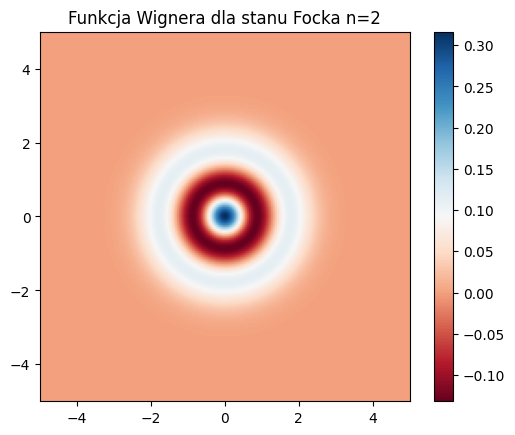

In [85]:
plt.imshow(W, cmap='RdBu', extent=[-5, 5, -5, 5])
plt.colorbar()
plt.title("Funkcja Wignera dla stanu Focka n=2")
plt.show()